<a href="https://colab.research.google.com/github/NBK-code/Q-Learning/blob/main/Q_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

In [32]:
class GridWorld:
    def __init__(self, size=10, stochastic=True):
        self.size = size
        self.start = (0, 0)
        self.goal = (size - 1, size - 1)
        self.state = self.start
        self.max_steps = 300
        self.steps = 0
        self.stochastic = stochastic

        self.action_space = 4

        self.walls = set([
            (1,2), (2,2), (3,2),
            (5,5), (5,6), (5,7),
            (7,3), (8,3),
            (10,7), (10,8), (10,9), (10,10), (10,11), (10,12),
            (1,8), (2,8), (2,9), (2,10),
            (16,14), (16,15), (16,16),
            (1,17), (2,17), (3,17), (4,17), (5,17),
            (8,17), (9,17), (10,17), (11,17), (12,17), (13,17),
            (13,16),
            (14,8), (15,8), (16,8),
            (17,1), (17,2), (17,3), (17,4)
        ])

    def reset(self):
        self.state = self.start
        self.steps = 0
        return self.state

    def step(self, action):
        self.steps += 1

        if self.stochastic and np.random.rand() < 0.2:
            action = np.random.choice(4)

        x, y = self.state
        nx, ny = x, y

        if action == 0:   # up
            nx = max(0, x - 1)
        elif action == 1: # down
            nx = min(self.size - 1, x + 1)
        elif action == 2: # left
            ny = max(0, y - 1)
        elif action == 3: # right
            ny = min(self.size - 1, y + 1)

        if (nx, ny) in self.walls:
            nx, ny = x, y

        self.state = (nx, ny)

        if self.state == self.goal:
            reward = 1.0
            done = True
        else:
            reward = -0.01
            done = False

        if self.steps >= self.max_steps:
            done = True

        return self.state, reward, done

In [33]:
def render_grid_pretty(env):
    grid = np.zeros((env.size, env.size))

    for (x, y) in env.walls:
        grid[x, y] = -1

    gx, gy = env.goal
    grid[gx, gy] = 2

    x, y = env.state
    grid[x, y] = 1

    cmap = ListedColormap([
        "black",   # walls
        "white",   # empty
        "crimson", # agent
        "lime"     # goal
    ])

    # map values to indices
    mapped = np.full_like(grid, 1)  # default empty

    mapped[grid == -1] = 0
    mapped[grid == 1] = 2
    mapped[grid == 2] = 3

    plt.figure(figsize=(6,6))
    plt.imshow(mapped, cmap=cmap)

    plt.xticks(np.arange(-.5, env.size, 1), [])
    plt.yticks(np.arange(-.5, env.size, 1), [])
    plt.grid(color='gray', linewidth=0.5)

    plt.title("Grid World")
    plt.show()

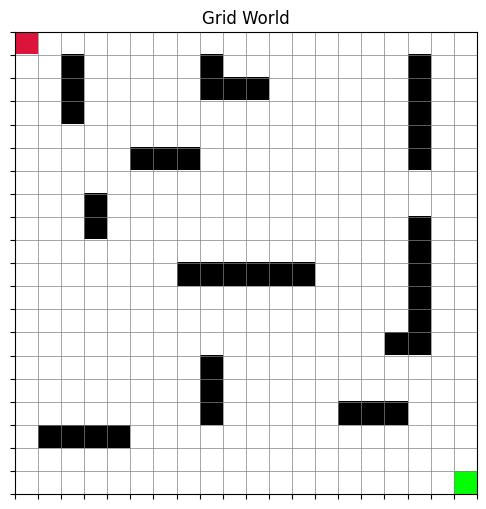

In [34]:
env = GridWorld(size=20)

env.reset()
render_grid_pretty(env)

In [35]:
Q = np.zeros((env.size, env.size, env.action_space))

In [36]:
def epsilon_greedy(Q, state, epsilon):
    if np.random.rand() < epsilon:
        return np.random.choice(4)
    else:
        x, y = state
        return np.argmax(Q[x, y])

In [37]:
def update_q(Q, state, action, reward, next_state, alpha, gamma):
    x, y = state
    nx, ny = next_state

    best_next = np.max(Q[nx, ny])

    Q[x, y, action] += alpha * (
        reward + gamma * best_next - Q[x, y, action]
    )

In [38]:
num_episodes = 2000
alpha = 0.1
gamma = 0.99
epsilon = 1.0
epsilon_decay = 0.995
epsilon_min = 0.05

rewards = []

for episode in range(num_episodes):
    state = env.reset()
    total_reward = 0

    done = False

    while not done:
        action = epsilon_greedy(Q, state, epsilon)

        next_state, reward, done = env.step(action)

        update_q(Q, state, action, reward, next_state, alpha, gamma)

        state = next_state
        total_reward += reward

    rewards.append(total_reward)

    epsilon = max(epsilon_min, epsilon * epsilon_decay)

    if episode % 50 == 0:
        print(f"Episode {episode}, Reward: {total_reward:.2f}")

Episode 0, Reward: -3.00
Episode 50, Reward: -3.00
Episode 100, Reward: -3.00
Episode 150, Reward: -3.00
Episode 200, Reward: -0.30
Episode 250, Reward: -3.00
Episode 300, Reward: -0.40
Episode 350, Reward: -1.18
Episode 400, Reward: -3.00
Episode 450, Reward: -0.00
Episode 500, Reward: -1.48
Episode 550, Reward: -0.01
Episode 600, Reward: 0.04
Episode 650, Reward: -0.05
Episode 700, Reward: -0.08
Episode 750, Reward: 0.06
Episode 800, Reward: 0.37
Episode 850, Reward: -0.08
Episode 900, Reward: -0.14
Episode 950, Reward: 0.46
Episode 1000, Reward: 0.39
Episode 1050, Reward: 0.34
Episode 1100, Reward: 0.30
Episode 1150, Reward: 0.50
Episode 1200, Reward: 0.43
Episode 1250, Reward: 0.44
Episode 1300, Reward: 0.54
Episode 1350, Reward: 0.49
Episode 1400, Reward: 0.50
Episode 1450, Reward: 0.50
Episode 1500, Reward: 0.50
Episode 1550, Reward: 0.63
Episode 1600, Reward: 0.47
Episode 1650, Reward: 0.47
Episode 1700, Reward: 0.43
Episode 1750, Reward: 0.53
Episode 1800, Reward: 0.52
Episode 

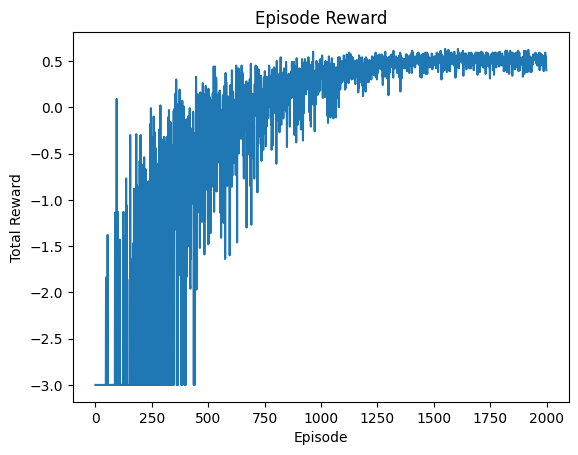

In [39]:
import matplotlib.pyplot as plt

plt.plot(rewards)
plt.title("Episode Reward")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.show()

In [40]:
action_arrows = {
    0: "↑",
    1: "↓",
    2: "←",
    3: "→"
}

def plot_policy(Q, env):
    for i in range(env.size):
        row = []
        for j in range(env.size):
            if (i, j) in env.walls:
                row.append("█")
            elif (i, j) == env.goal:
                row.append("G")
            else:
                a = np.argmax(Q[i, j])
                row.append(action_arrows[a])
        print(" ".join(row))

In [41]:
plot_policy(Q, env)

→ → → → → → ↓ ↓ → ↑ ↑ ↓ ↓ ↑ → → ↓ ↓ ↓ →
→ ↑ █ → ↓ ↓ ↓ ↓ █ → → ↓ ↑ ↓ ↓ ↓ ← █ ↓ →
↓ ↓ █ → → → → ↓ █ █ █ ↓ ↓ ↓ ↓ ↓ ↓ █ → →
↓ ↓ █ ↑ ↓ ↓ → ↓ → → ↓ ↓ ↓ → ↓ ↓ ↓ █ ↑ ↓
↓ ↓ ↓ → ↓ → → → ↓ → ↓ → ↓ → → ↓ ↓ █ ↓ ←
↓ ↓ ↓ ↓ ↓ █ █ █ → → → ↓ ↓ → → ↓ ↓ █ ↓ ↓
↓ → → → → ↓ → → ↓ ↓ ↓ ↓ ↓ → ↓ ↓ ↓ ↓ ↓ ↓
↓ ↓ ↓ █ → ↓ → → → → → → ↓ → → ↓ → → ↓ ↓
↓ ↓ ↓ █ → ↓ ↓ → → → ↓ → ↓ ↓ ↓ ↓ ↓ █ → ↓
↓ ↓ ↓ ↓ ↓ → ↓ ← → → → → → → ↓ ↓ ↓ █ → ↓
→ ↓ ↓ ↓ → ↓ ↓ █ █ █ █ █ █ ↓ ↓ ↓ ↓ █ → ↓
→ ↓ ↓ ↓ → → → → ↓ ↓ ↓ ↑ ↓ → → ↓ ← █ ↓ ↓
→ → ↓ ↓ ↓ ↓ ↓ → → ↓ → ↓ ↓ ↓ ↓ ↓ ← █ ↓ ↓
→ → → → → → → → → ↓ ↓ → ↓ ↓ → ↓ █ █ ↓ ↓
↑ → → ↑ → ↓ → ↑ █ → → → → ↓ → ↓ ↓ ↓ → ↓
↑ ↓ ↑ ↑ ↓ ↓ ↓ ↓ █ ↑ ↓ → → ↓ → → → ↓ → ↓
→ ↑ → → → ↓ → ↓ █ ↓ → ↓ ↓ ↓ █ █ █ ↓ → ↓
← █ █ █ █ ↓ ↓ → ↓ → ↓ → → ↓ → ↓ → ↓ → ↓
↓ ← → → → → → → → ↓ → → → → ↓ → → → → ↓
↑ ← ↓ ↑ ↑ ↓ → → → → → → → → → → → → → G


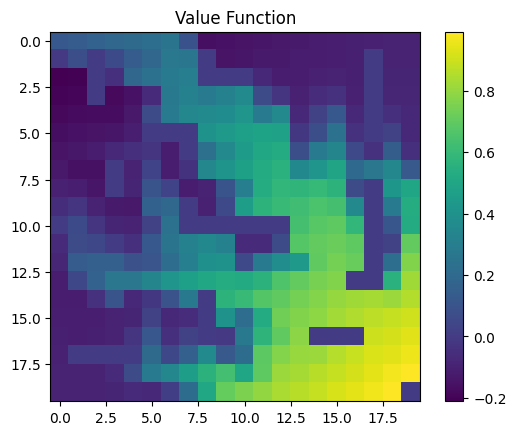

In [42]:
V = np.max(Q, axis=2)

plt.imshow(V)
plt.colorbar()
plt.title("Value Function")
plt.show()

In [43]:
def greedy_policy(Q, state):
    x, y = state
    return np.argmax(Q[x, y])

In [44]:
def run_learned_policy(env, Q, render=True, delay=0.1):
    import time

    state = env.reset()
    total_reward = 0
    done = False

    if render:
        render_grid_pretty(env)

    while not done:
        action = greedy_policy(Q, state)

        next_state, reward, done = env.step(action)

        total_reward += reward
        state = next_state

        if render:
            time.sleep(delay)
            render_grid_pretty(env)

    print(f"Final Reward: {total_reward:.2f}")

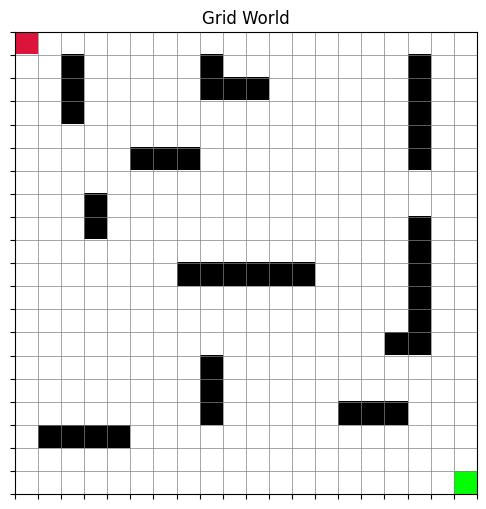

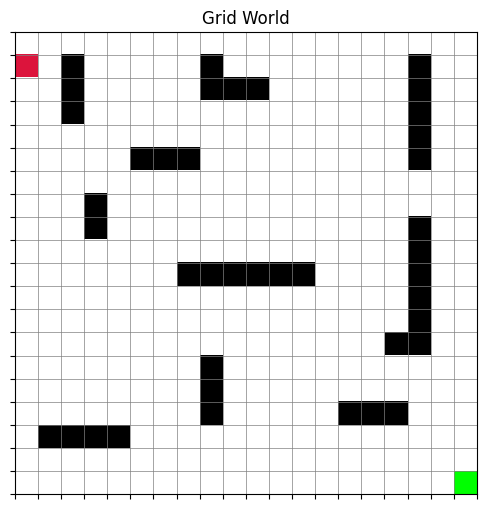

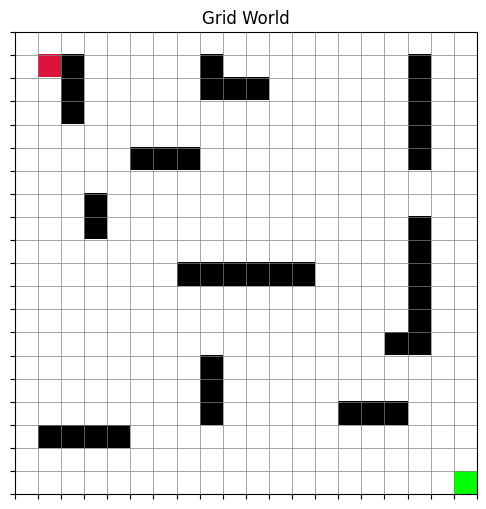

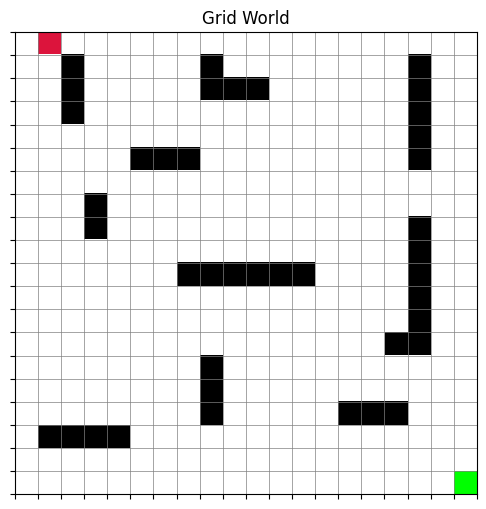

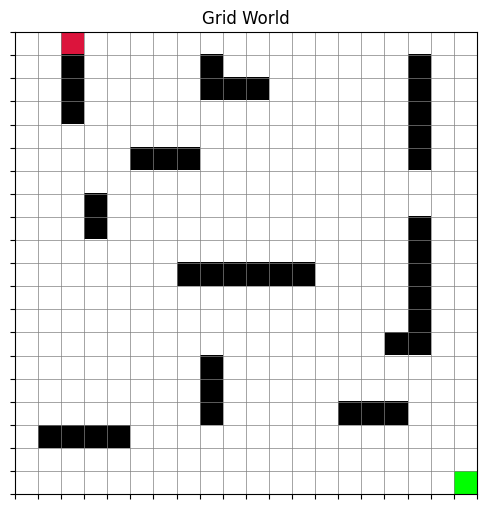

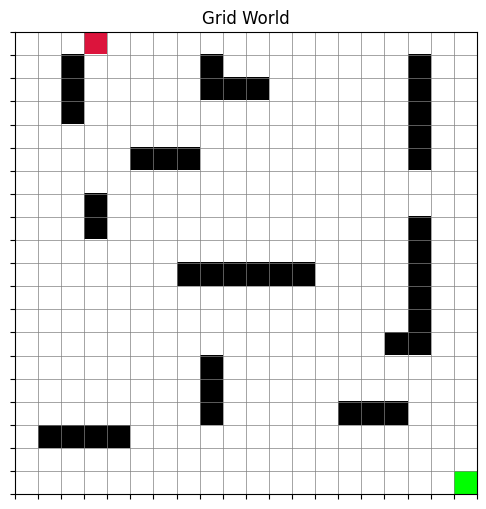

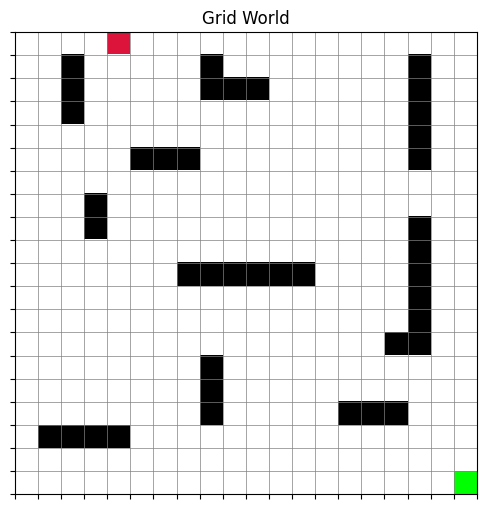

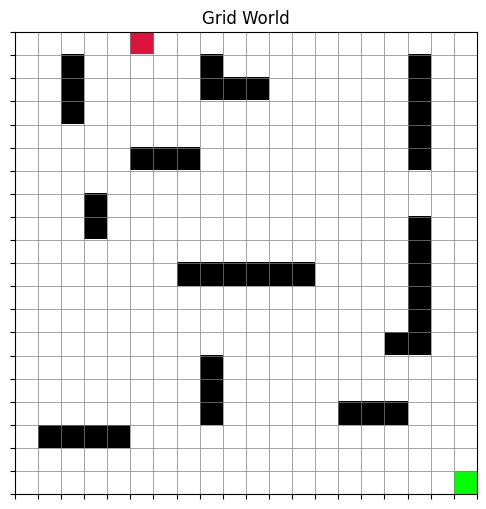

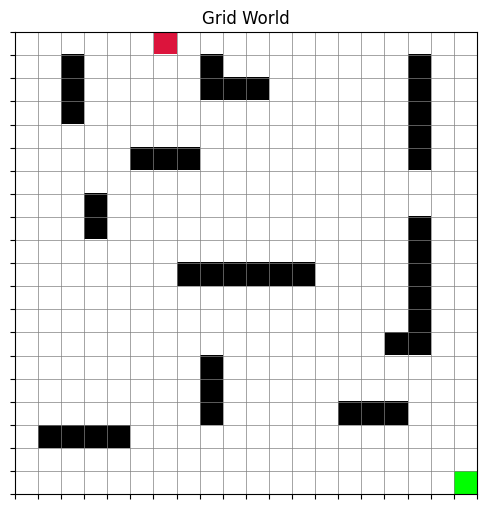

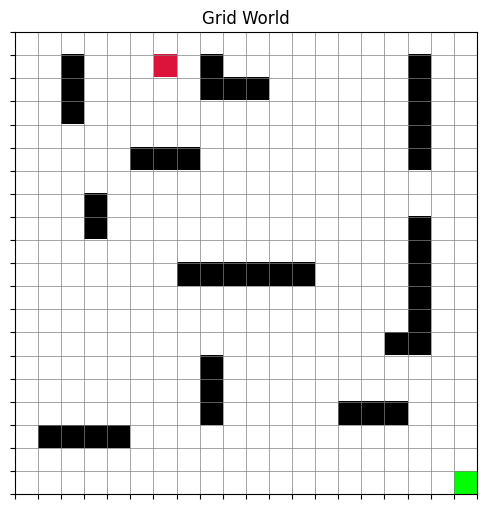

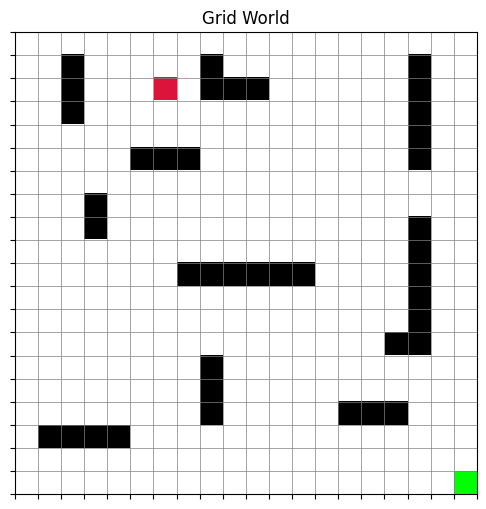

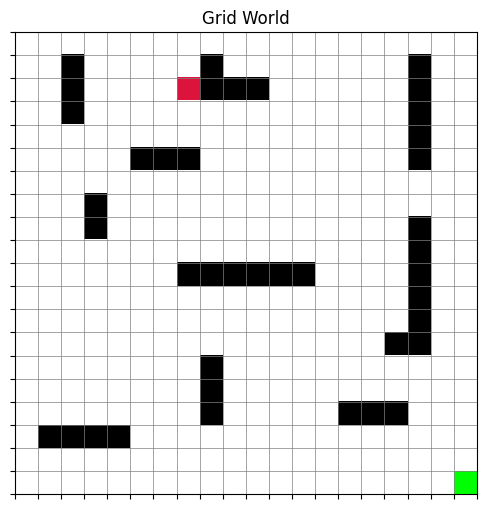

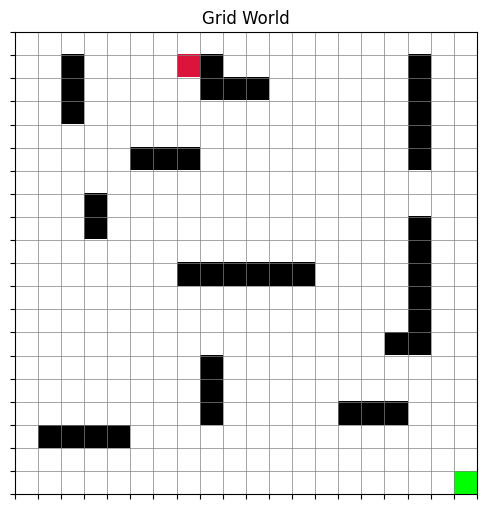

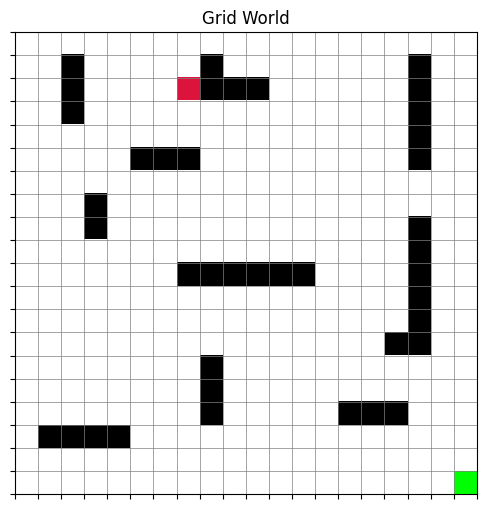

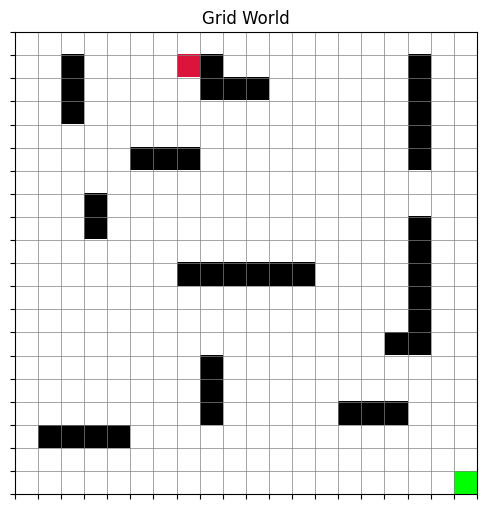

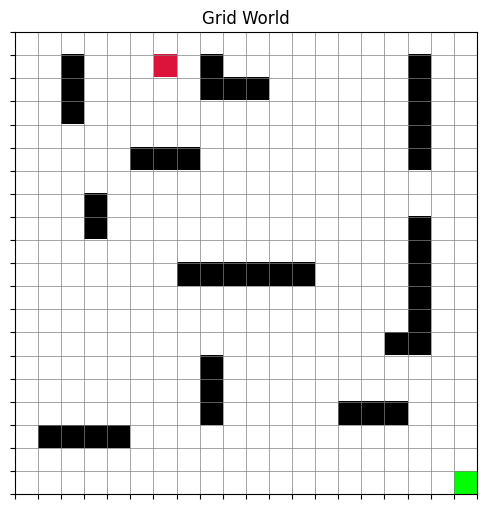

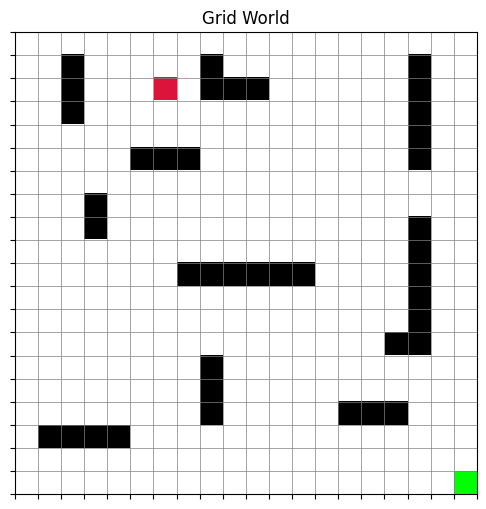

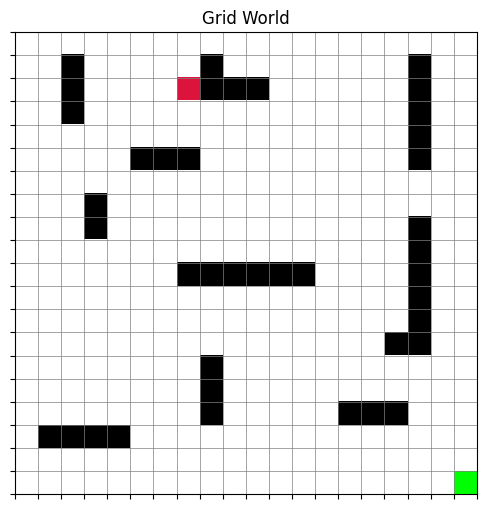

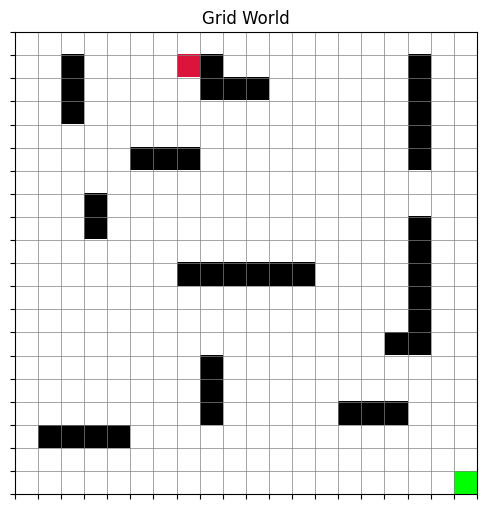

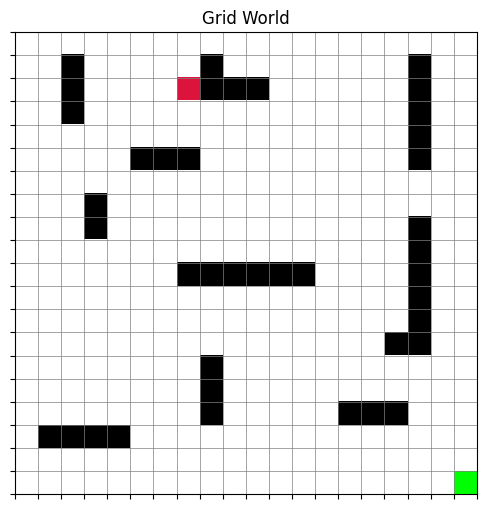

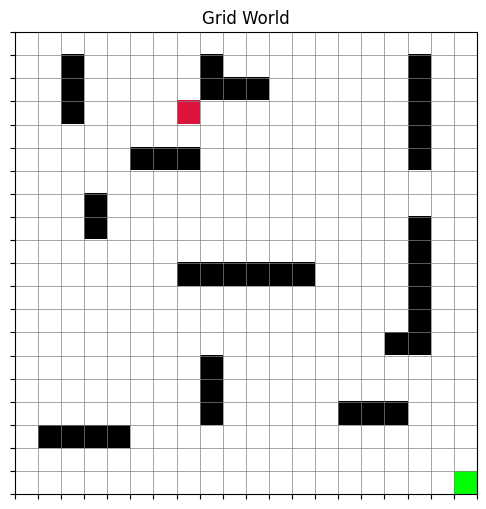

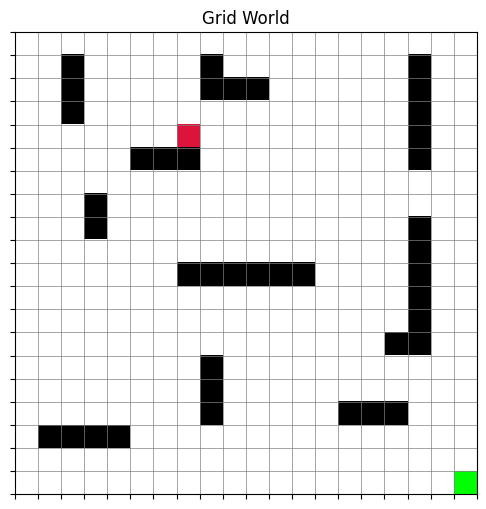

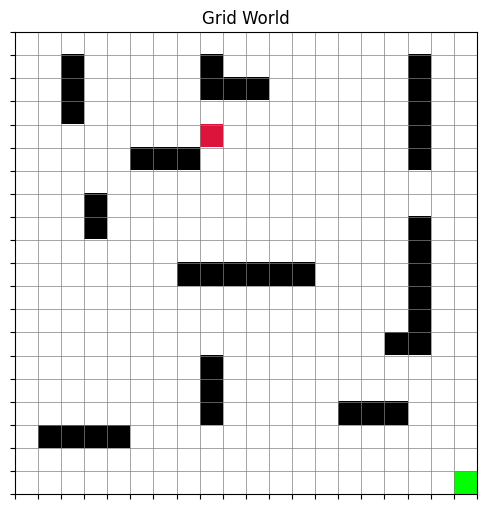

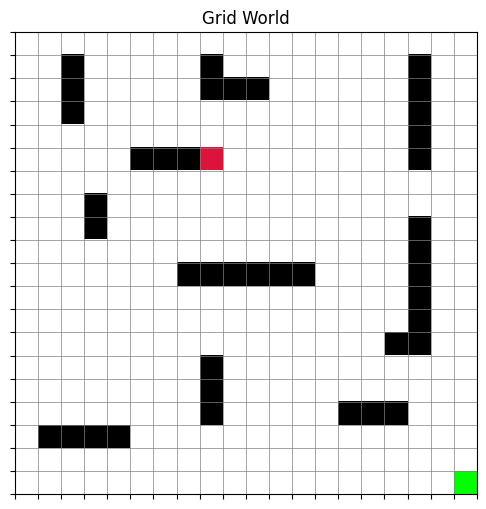

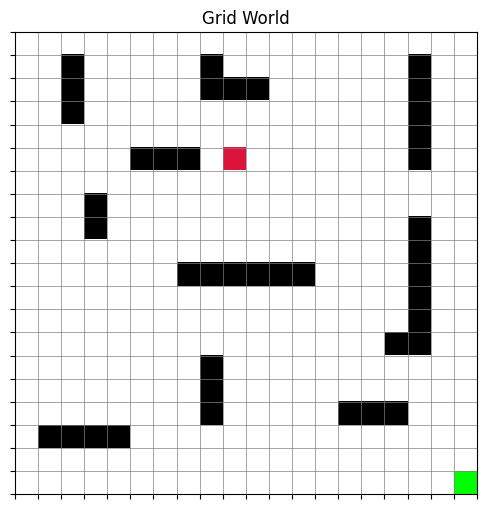

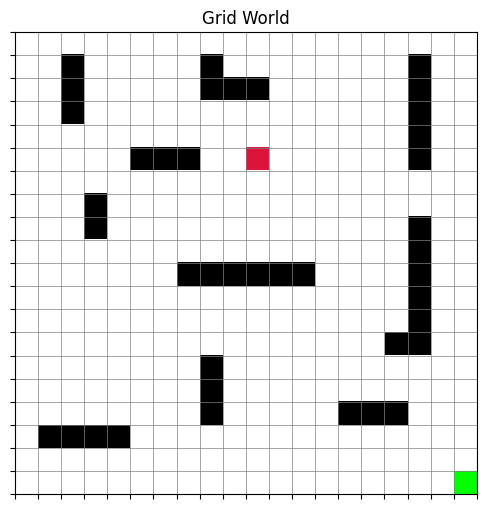

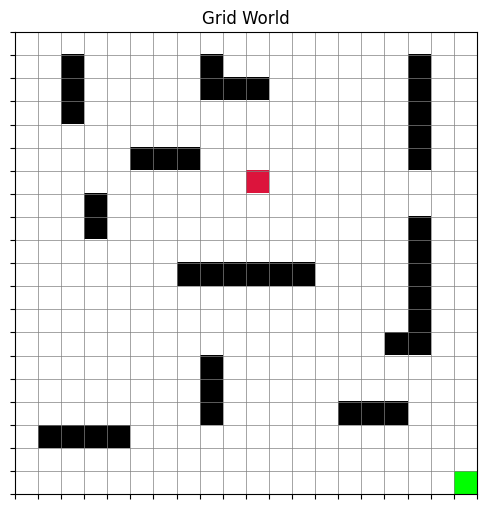

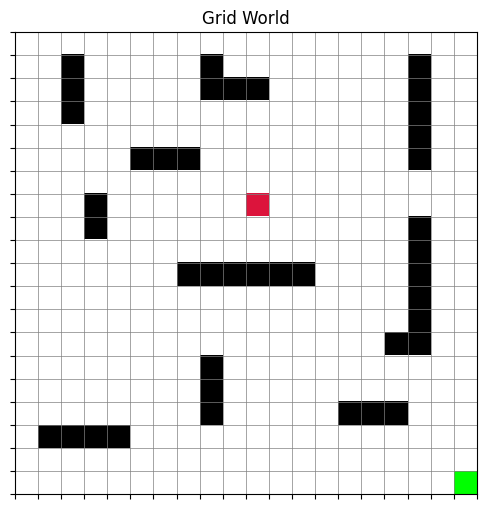

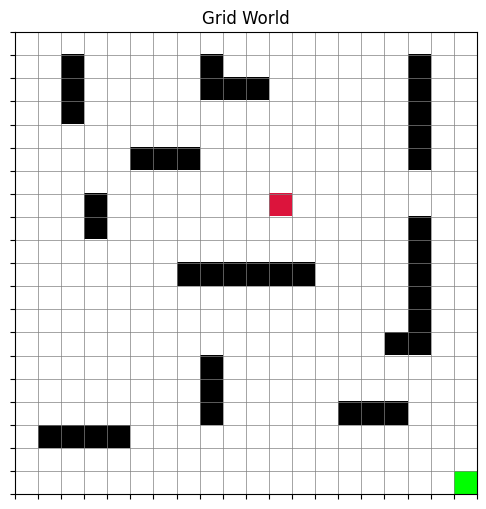

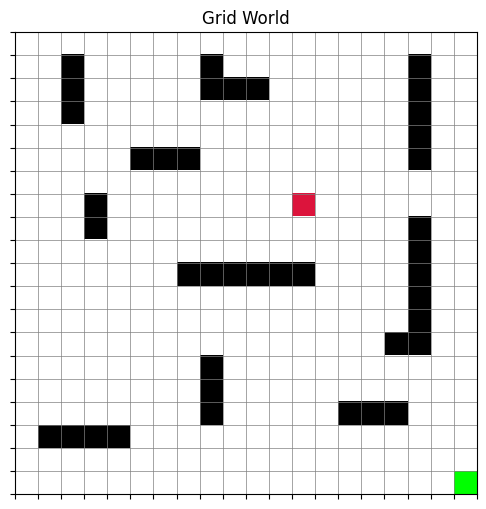

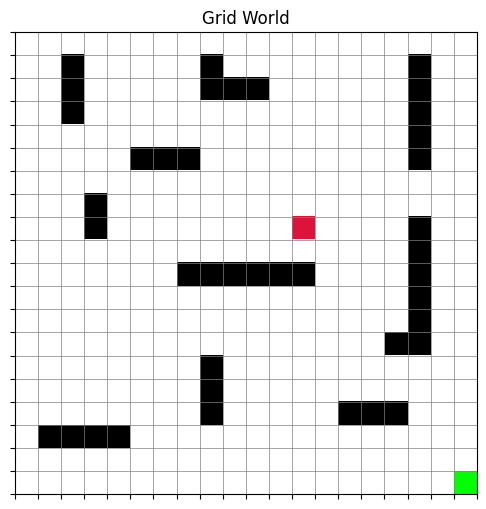

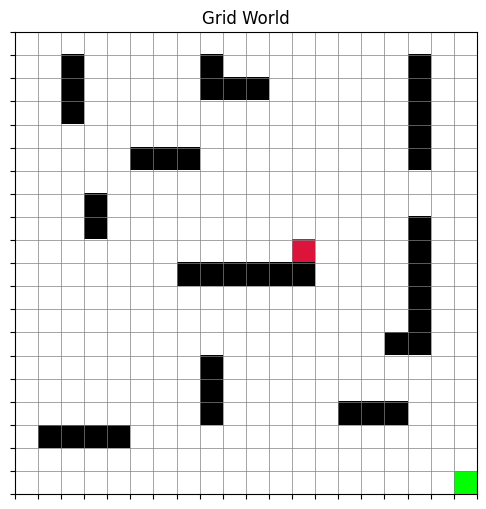

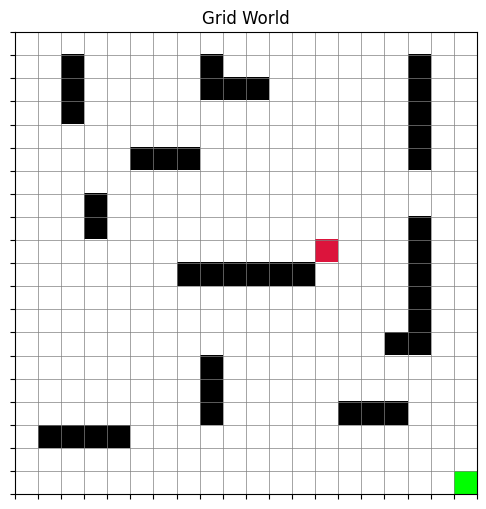

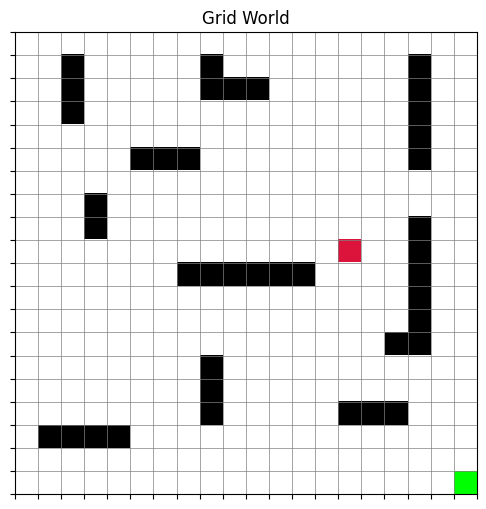

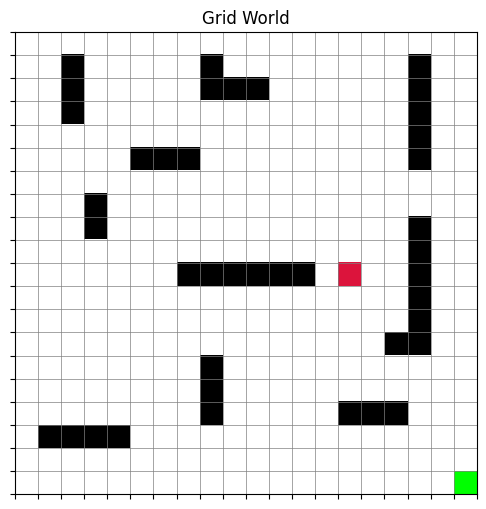

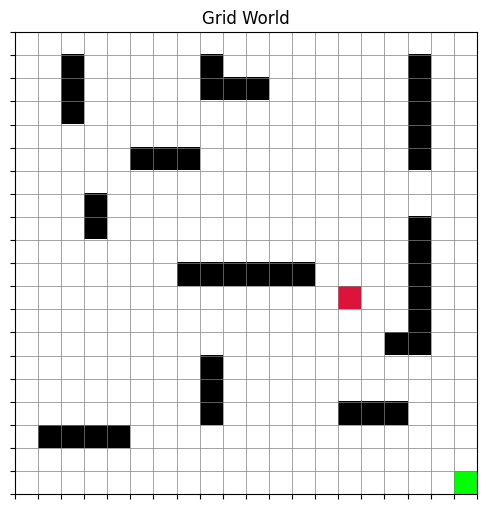

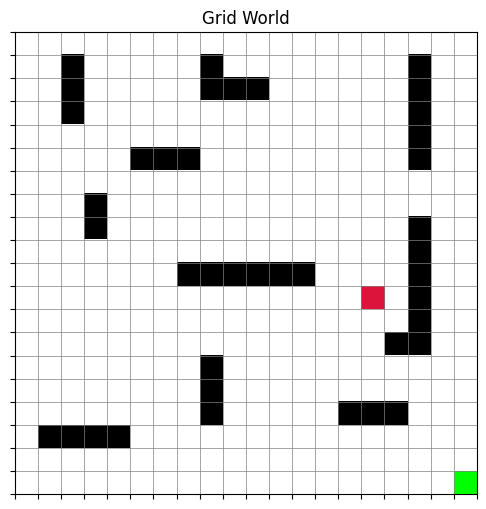

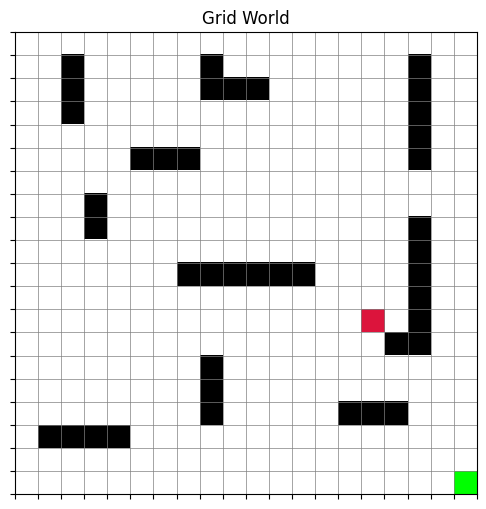

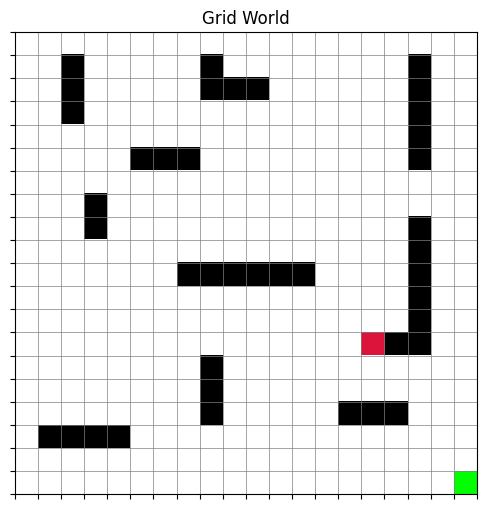

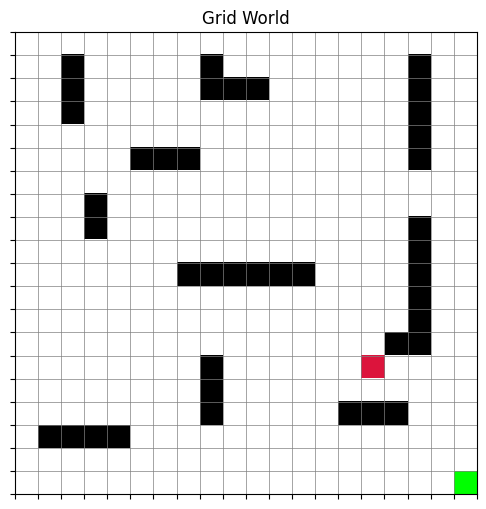

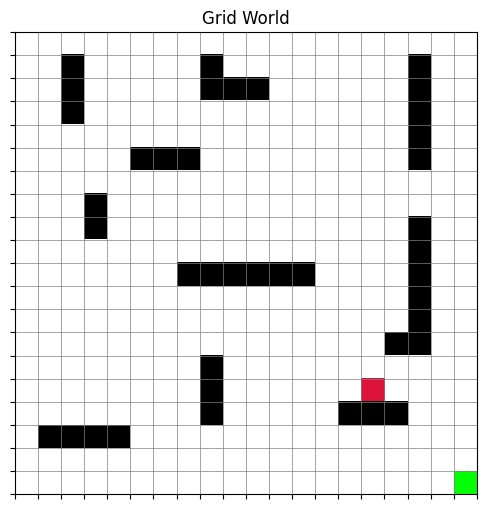

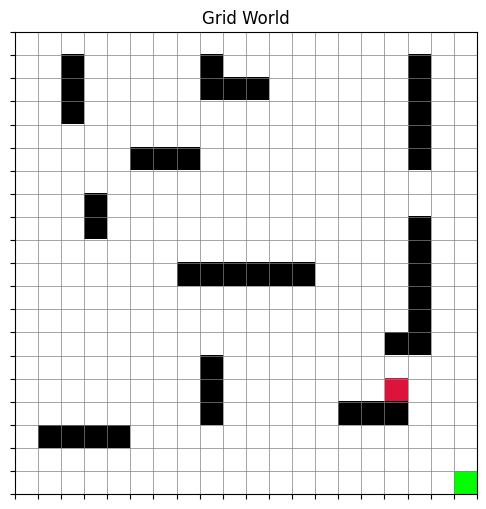

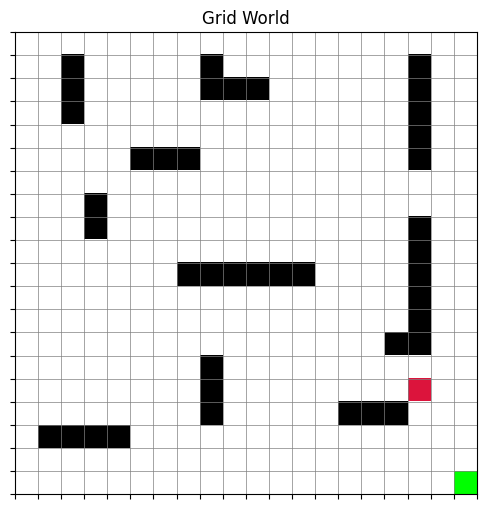

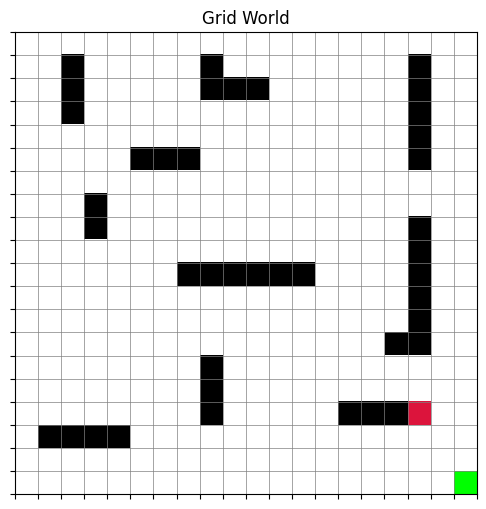

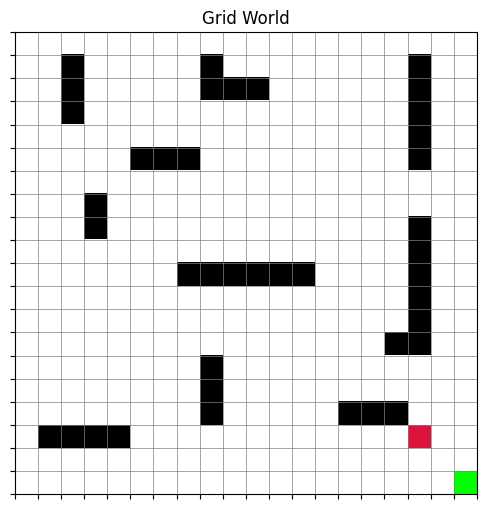

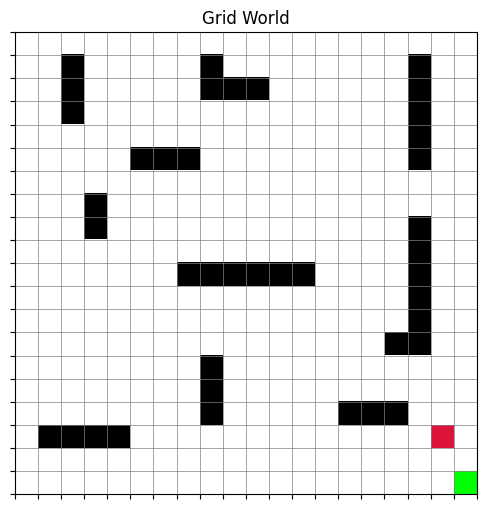

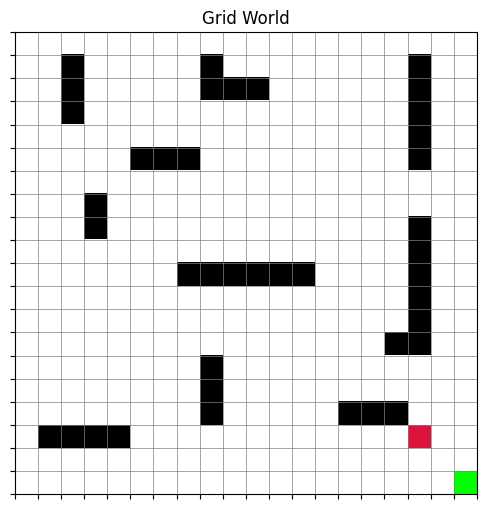

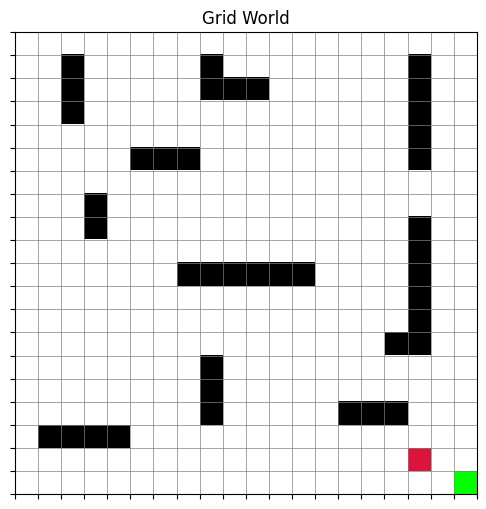

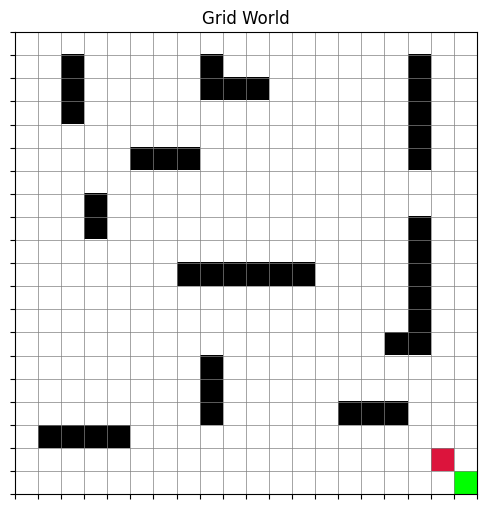

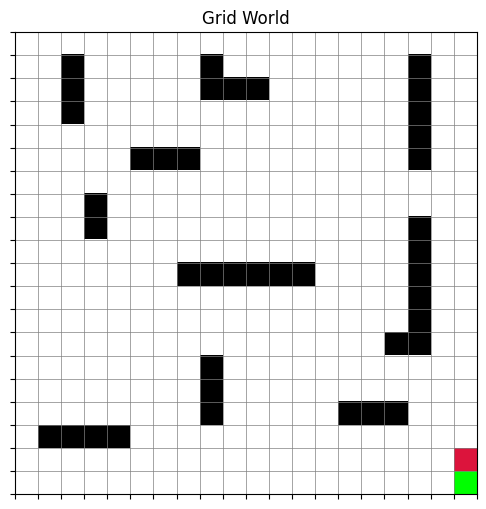

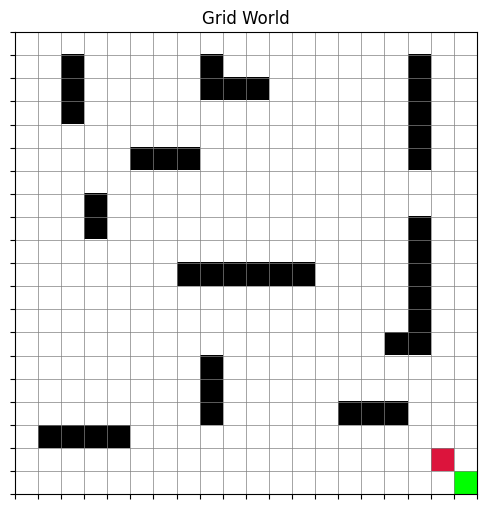

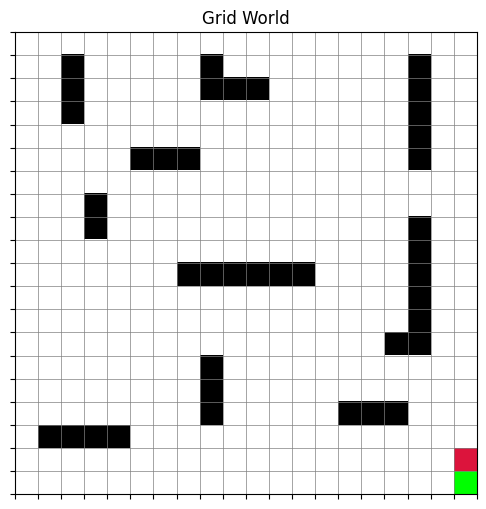

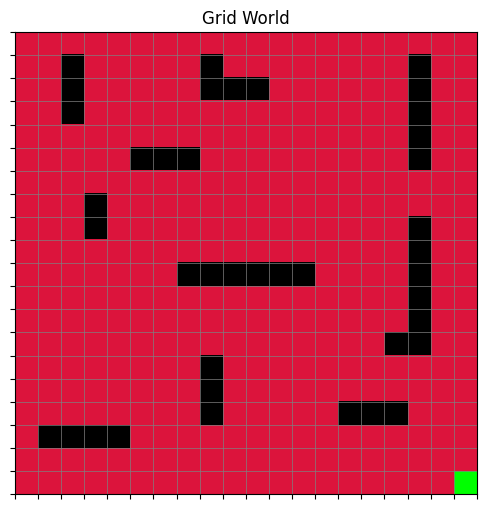

Final Reward: 0.49


In [45]:
run_learned_policy(env, Q)

In [46]:
def evaluate_policy(env, Q, episodes=50):
    total_rewards = []

    for _ in range(episodes):
        state = env.reset()
        done = False
        total_reward = 0

        while not done:
            action = greedy_policy(Q, state)
            state, reward, done = env.step(action)
            total_reward += reward

        total_rewards.append(total_reward)

    print(f"Average Reward: {np.mean(total_rewards):.3f}")
    print(f"Std Reward: {np.std(total_rewards):.3f}")

In [47]:
evaluate_policy(env, Q)

Average Reward: 0.519
Std Reward: 0.056
